In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim, dropout):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.GRU(emb_dim, hid_dim, bidirectional=True)
        self.fc = nn.Linear(hid_dim * 2, hid_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_len):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded, src_len.to('cpu'), enforce_sorted=False)
        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs)
        hidden = torch.tanh(self.fc(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)))
        return outputs, hidden

class Attention(nn.Module):
    def __init__(self, hid_dim, method="additive"):
        super().__init__()
        self.method = method
        if method == "additive":
            self.W = nn.Linear(hid_dim, hid_dim)
            self.U = nn.Linear(hid_dim * 2, hid_dim)
            self.v = nn.Linear(hid_dim, 1, bias=False)
        else: # general
            self.W = nn.Linear(hid_dim, hid_dim * 2)

    def forward(self, hidden, encoder_outputs, mask):
        src_len = encoder_outputs.shape[0]
        s = hidden.unsqueeze(1).repeat(1, src_len, 1)
        projected_encoder = encoder_outputs.permute(1, 0, 2)
        
        if self.method == "additive":
            energy = torch.tanh(self.W(s) + self.U(projected_encoder))
            energy = self.v(energy).squeeze(2)
        else:
            s = self.W(hidden).unsqueeze(2)
            energy = torch.bmm(projected_encoder, s).squeeze(2)
            
        energy = energy.masked_fill(mask, -1e4)
        return F.softmax(energy, dim=1)

class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, dropout, attention):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.GRU((hid_dim * 2) + emb_dim, hid_dim)
        self.fc = nn.Linear((hid_dim * 2) + hid_dim + emb_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, encoder_outputs, mask):
        input = input.unsqueeze(0)
        embedded = self.dropout(self.embedding(input))
        a = self.attention(hidden, encoder_outputs, mask)
        a_unsqueezed = a.unsqueeze(1)
        enc_perm = encoder_outputs.permute(1, 0, 2)
        weighted = torch.bmm(a_unsqueezed, enc_perm).permute(1, 0, 2)
        rnn_input = torch.cat((embedded, weighted), dim=2)
        output, hidden = self.rnn(rnn_input, hidden.unsqueeze(0))
        prediction = self.fc(torch.cat((output.squeeze(0), weighted.squeeze(0), embedded.squeeze(0)), dim=1))
        return prediction, hidden.squeeze(0), a

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.device = device

    def create_mask(self, src):
        mask = (src == self.src_pad_idx).permute(1, 0)
        return mask

In [22]:
INPUT_DIM = 6159  
OUTPUT_DIM = 7880 
ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
HID_DIM = 512
ENC_DROPOUT = 0.5
DEC_DROPOUT = 0.5
SRC_PAD_IDX = 1

attn = Attention(HID_DIM, method="additive")
enc = Encoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM, ENC_DROPOUT)
dec = Decoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM, DEC_DROPOUT, attn)
model = Seq2Seq(enc, dec, SRC_PAD_IDX, device).to(device)

# Load the saved best model
checkpoint = torch.load('checkpoints/Additive_Attention_best.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(6159, 256)
    (rnn): GRU(256, 512, bidirectional=True)
    (fc): Linear(in_features=1024, out_features=512, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (decoder): Decoder(
    (attention): Attention(
      (W): Linear(in_features=512, out_features=512, bias=True)
      (U): Linear(in_features=1024, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(7880, 256)
    (rnn): GRU(1280, 512)
    (fc): Linear(in_features=1792, out_features=7880, bias=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
)

In [15]:
def display_attention_text(sentence, translation, attention):
    # Scale: 0 to 1 represented by intensity of blocks
    chars = [" ", "░", "▒", "▓", "█"]
    
    # Header: Source tokens (English)
    header = " " * 15 + "  ".join([f"{tok:>8}" for tok in sentence])
    print("\n" + header)
    print("-" * len(header))

    attention = attention.squeeze(1).cpu().detach().tolist()

    for i, trg_tok in enumerate(translation):
        row_str = f"{trg_tok:>15} | "
        for j in range(len(sentence)):
            attn_val = attention[i][j]
            # Map attention (0.0 - 1.0) to a block character
            char_idx = min(int(attn_val * len(chars)), len(chars) - 1)
            row_str += f" {chars[char_idx]}{attn_val:.2f}  "
        print(row_str)

def translate_and_visualize_text(model, src_sentence, src_vocab, trg_vocab, device, max_len=50):
    model.eval()
    
    tokens = [token.lower() for token in src_sentence]
    src_indexes = [src_vocab['<sos>']] + [src_vocab[token] for token in tokens] + [src_vocab['<eos>']]
    src_tensor = torch.LongTensor(src_indexes).unsqueeze(1).to(device)
    src_len = torch.LongTensor([len(src_indexes)])
    
    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor, src_len)

    mask = model.create_mask(src_tensor)
    trg_indexes = [trg_vocab['<sos>']]
    attentions = torch.zeros(max_len, 1, len(src_indexes))
    
    for i in range(max_len):
        trg_tensor = torch.LongTensor([trg_indexes[-1]]).to(device)
        with torch.no_grad():
            output, hidden, attention = model.decoder(trg_tensor, hidden, encoder_outputs, mask)
        
        attentions[i] = attention
        pred_token = output.argmax(1).item()
        trg_indexes.append(pred_token)
        if pred_token == trg_vocab['<eos>']: break
            
    trg_tokens = [trg_vocab.get_itos()[i] for i in trg_indexes]
    
    # Call the text-based visualizer
    display_attention_text(tokens + ['<eos>'], trg_tokens[1:], attentions[:len(trg_tokens)-1])
    
    return "".join(trg_tokens[1:-1]) # Return as a string for readability

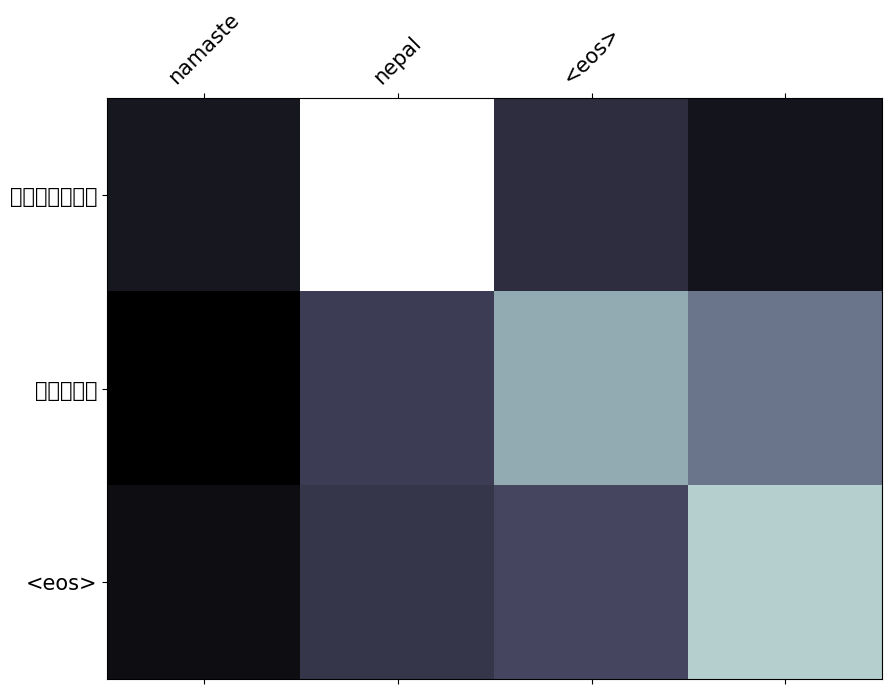

In [20]:
import pickle

with open('assets/vocab_transform.pkl', 'rb') as f:
    vocab_transform = pickle.load(f)

# Define the variables for your visualization function
en_vocab = vocab_transform['en']
ne_vocab = vocab_transform['ne']

# Now you can run the visualizationa
translated_tokens = translate_and_visualize(model, ["namaste", "nepal"], en_vocab, ne_vocab, device)

In [21]:
# Example sentence
sentence = "the weather is very nice today"
tokens = sentence.split()
# Run the visualization
translation = translate_and_visualize_text(
    model, 
    tokens, 
    en_vocab, 
    ne_vocab, 
    device
)

print(f"\nFinal Translation: {translation}")


                    the   weather        is      very      nice     today     <eos>
-----------------------------------------------------------------------------------
           मौसम |   0.14    0.05   ▒0.55    0.03    0.07    0.03    0.06  
          <unk> |   0.07    0.02   ░0.33    0.02    0.08    0.06    0.17  
           आजको |   0.08    0.01    0.18    0.04    0.12    0.16    0.20  
          <unk> |   0.11    0.01    0.16    0.05    0.15   ░0.23    0.10  
          <eos> |   0.20    0.02    0.05    0.07    0.12   ░0.28    0.05  

Final Translation: मौसम<unk>आजको<unk>
